<a href="https://colab.research.google.com/github/galarconc/Razonamiento-Basado-en-Datos/blob/main/Copia_de_Week01_vibecoding_rbd_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

file_path = '/content/drive/MyDrive/1.-ClasesyColabsRazonamiento/Clases/Week1:AnalyticsFramework/IndoCabs_Control_Excel_Estudiantes.xlsx'
df = pd.read_excel(file_path)

print("Excel file loaded successfully!")
display(df.head())

Excel file loaded successfully!


,record,id,user_id,vehicle_model_id,travel_type_id,from_area_id,to_area_id,from_date,to_date,online_booking,mobile_site_booking,booking_created,car_cancellation
0,1,176196,43860,12,2,585.0,172.0,2013-09-29 20:45:00,2013-09-29 21:01:03.936,1,0,2013-09-29 14:38:00,0
1,2,161566,37032,12,2,1274.0,393.0,2013-07-20 04:00:00,2013-07-20 05:13:23.232,1,0,2013-07-19 21:31:00,0
2,3,176287,39899,12,2,1288.0,1361.0,2013-09-29 22:00:00,2013-09-29 23:55:07.104,1,0,2013-09-29 20:30:00,0
3,4,169337,33292,89,2,142.0,1254.0,2013-08-26 10:00:00,2013-08-26 11:01:39.936,1,0,2013-08-26 01:02:00,0
4,5,166571,39253,12,2,253.0,1189.0,2013-08-21 02:45:00,2013-08-21 03:23:05.856,0,0,2013-08-13 10:07:00,0


### a) Crear la columna 'Duration (Hours)'

Primero, me aseguraré de que las columnas `from_date` y `to_date` sean de tipo datetime. Luego, calcularé la diferencia entre `to_date` y `from_date` y la convertiré a horas. Si `to_date` está vacía (indicando una reserva cancelada), la duración se dejará en blanco (NaN).

In [ ]:
import numpy as np

# Convertir las columnas de fecha a tipo datetime, si no lo están ya
df['from_date'] = pd.to_datetime(df['from_date'])
df['to_date'] = pd.to_datetime(df['to_date'])

# Calcular la duración en horas
# La resta de NaT (Not a Time) con un datetime resultará en NaT, que al convertir a horas será NaN
df['Duration (Hours)'] = (df['to_date'] - df['from_date']).dt.total_seconds() / 3600

display(df[['from_date', 'to_date', 'Duration (Hours)']].head())

,from_date,to_date,Duration (Hours)
0,2013-09-29 20:45:00,2013-09-29 21:01:03.936,0.26776
1,2013-07-20 04:00:00,2013-07-20 05:13:23.232,1.22312
2,2013-09-29 22:00:00,2013-09-29 23:55:07.104,1.91864
3,2013-08-26 10:00:00,2013-08-26 11:01:39.936,1.02776
4,2013-08-21 02:45:00,2013-08-21 03:23:05.856,0.63496


### b) Crear la columna 'Duration Category'

Ahora, clasificaré cada viaje en 'Cancelled', 'Short', 'Medium' o 'Long' basándome en la columna 'Duration (Hours)'.

In [ ]:
def categorize_duration(duration_hours):
    if pd.isna(duration_hours):
        return 'Cancelled'
    elif duration_hours <= 2:
        return 'Short'
    elif duration_hours <= 6:
        return 'Medium'
    else:
        return 'Long'

df['Duration Category'] = df['Duration (Hours)'].apply(categorize_duration)

display(df[['Duration (Hours)', 'Duration Category']].head())

,Duration (Hours),Duration Category
0,0.26776,Short
1,1.22312,Short
2,1.91864,Short
3,1.02776,Short
4,0.63496,Short


### c) Crear la columna 'BookingWindow'

Ahora, calcularé la diferencia entre la fecha de creación de la reserva (`booking_created`) y la fecha de inicio del viaje (`from_date`).

In [ ]:
import pandas as pd

# Asegurarse de que 'booking_created' sea de tipo datetime
df['booking_created'] = pd.to_datetime(df['booking_created'])

# Calcular la 'BookingWindow' (diferencia entre from_date y booking_created)
df['BookingWindow'] = df['from_date'] - df['booking_created']

# Mostrar las columnas relevantes y las primeras filas para verificar
display(df[['booking_created', 'from_date', 'BookingWindow']].head())

,booking_created,from_date,BookingWindow
0,2013-09-29 14:38:00,2013-09-29 20:45:00,0 days 06:07:00
1,2013-07-19 21:31:00,2013-07-20 04:00:00,0 days 06:29:00
2,2013-09-29 20:30:00,2013-09-29 22:00:00,0 days 01:30:00
3,2013-08-26 01:02:00,2013-08-26 10:00:00,0 days 08:58:00
4,2013-08-13 10:07:00,2013-08-21 02:45:00,7 days 16:38:00


### e) Crear Grupos de Ventana de Reserva (Booking Window Groups) y Analizar Tasa de Cancelación

Procederé a crear 5 grupos (G1 a G5) basados en los cuantiles de la columna `BookingWindow (Hours)`. Además, las reservas con una ventana de reserva indefinida (generalmente canceladas) se asignarán a un grupo especial. Posteriormente, calcularé el número de reservas y la tasa de cancelación para cada uno de estos grupos, y visualizaré los resultados.

,Group,total_bookings,Percentage of Bookings (%),Cancellation Rate (%)
0,G1,5041,20.048521,12.497520
1,G2,5024,19.980910,12.141720
2,G3,5023,19.976933,7.883735
3,G4,5028,19.996818,4.634049
4,G5,5028,19.996818,5.847255
5,Cancelled/Undefined Booking Window,0,0.000000,NaN


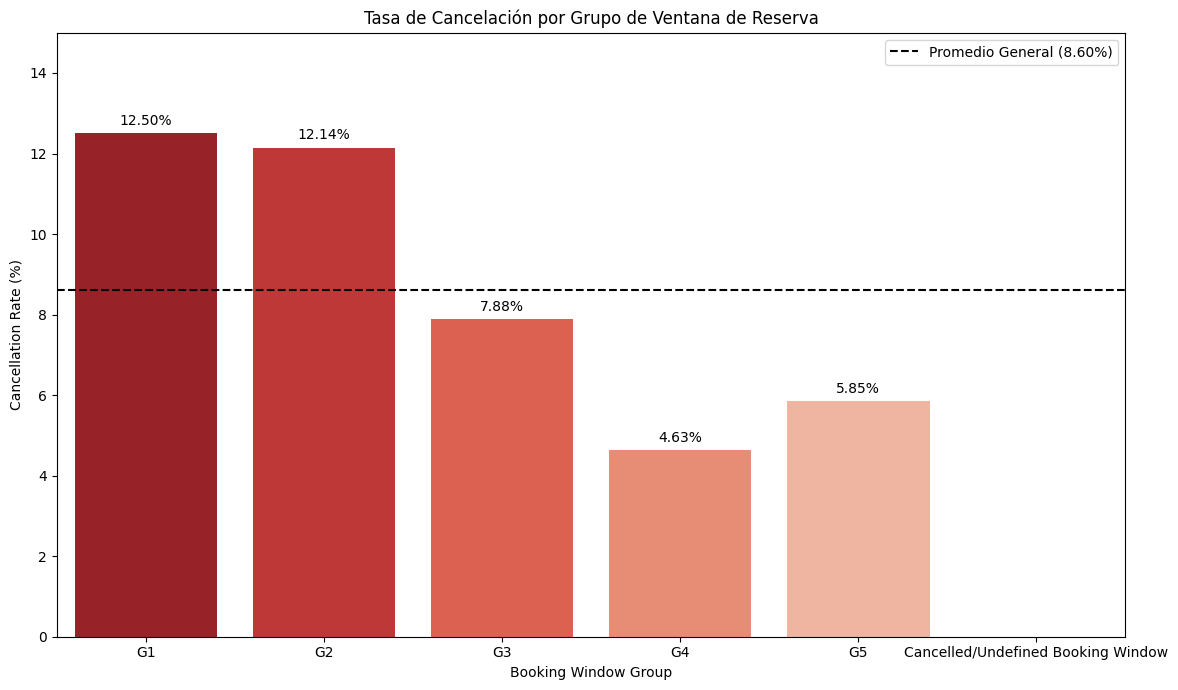

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Definir Grupos de Ventana de Reserva (G1-G5)
df['BookingWindowGroup'] = pd.qcut(
    df['BookingWindow (Hours)'],
    q=5,
    labels=['G1', 'G2', 'G3', 'G4', 'G5'],
    duplicates='drop'
)

# 2. Manejar entradas de BookingWindowGroup no agrupadas (NaN)
df['BookingWindowGroup'] = df['BookingWindowGroup'].cat.add_categories('Cancelled/Undefined Booking Window').fillna('Cancelled/Undefined Booking Window')

# Asegurar el orden correcto de las categorías
booking_group_order = ['G1', 'G2', 'G3', 'G4', 'G5', 'Cancelled/Undefined Booking Window']
df['BookingWindowGroup'] = pd.Categorical(df['BookingWindowGroup'], categories=booking_group_order, ordered=True)

# 3. Calcular Métricas por Grupo
grouped_data = df.groupby('BookingWindowGroup', observed=False).agg(
    total_bookings=('record', 'count'),
    cancelled_bookings=('Duration Category', lambda x: (x == 'Cancelled').sum())
).reset_index()

# Calcular porcentajes y tasas
total_all_bookings = grouped_data['total_bookings'].sum()
grouped_data['percent_of_bookings'] = (grouped_data['total_bookings'] / total_all_bookings) * 100
grouped_data['cancellation_rate'] = (grouped_data['cancelled_bookings'] / grouped_data['total_bookings']) * 100

# 4. Calcular la Tasa de Cancelación Promedio General
overall_cancellation_rate = (df['Duration Category'] == 'Cancelled').sum() / len(df) * 100

# 5. Preparar la Tabla de Resultados
results_table = grouped_data.rename(columns={
    'BookingWindowGroup': 'Group',
    'percent_of_bookings': 'Percentage of Bookings (%)',
    'cancellation_rate': 'Cancellation Rate (%)'
})

display(results_table[['Group', 'total_bookings', 'Percentage of Bookings (%)', 'Cancellation Rate (%)']])

# 6. Crear Gráfico de Barras con UN SOLO EJE (Cancellation Rate)
plt.figure(figsize=(12, 7))

# Graficar la Tasa de Cancelación directamente en el eje principal
ax = sns.barplot(x='Group', y='Cancellation Rate (%)', data=results_table, hue='Group', palette='Reds_r', legend=False)

# Trazar la tasa de cancelación promedio general como referencia
plt.axhline(overall_cancellation_rate, color='black', linestyle='--', label=f'Promedio General ({overall_cancellation_rate:.2f}%)')

# Configuración de etiquetas y títulos
plt.xlabel('Booking Window Group')
plt.ylabel('Cancellation Rate (%)')
plt.title('Tasa de Cancelación por Grupo de Ventana de Reserva')
plt.ylim(0, max(results_table['Cancellation Rate (%)'].fillna(0)) * 1.2)
plt.legend(loc='upper right')

# Añadir etiquetas de valor sobre las barras
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2f') + '%',
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 9),
                   textcoords = 'offset points')

plt.tight_layout()
plt.show()

### Reporte de Viajes por Categoría

Finalmente, voy a mostrar cuántos viajes caen en cada una de las 4 categorías.

In [ ]:
category_counts = df['Duration Category'].value_counts()
print("Número de viajes por categoría:")
display(category_counts)

Número de viajes por categoría:


,count
Duration Category,
Short,16221
Medium,3742
Long,3018
Cancelled,2163
